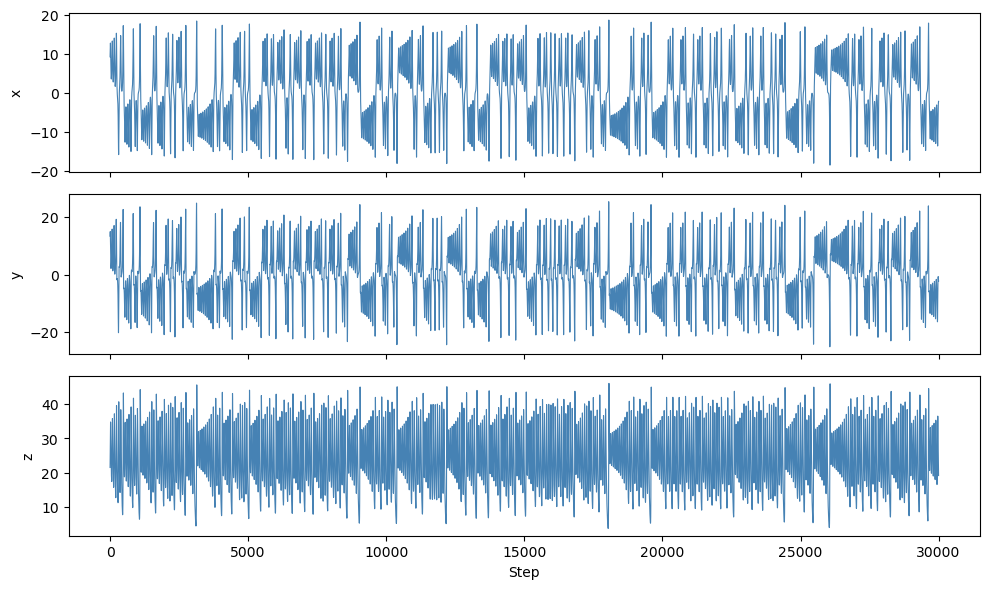

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from sklearn.linear_model import Lasso

reservoirpy.set_seed(42)

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..',)))
from lib.utils.reservoirpy import *

# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/lorenz_system.csv', delimiter=',')

# Expecting shape (T, 3) with columns = (x, y, z).
# If your CSV has an extra time column, do: dataset = dataset[:, 1:4]
assert dataset.ndim == 2 and dataset.shape[1] >= 3, \
    f"Expected (T, >=3) Lorenz array, got {dataset.shape}"
dataset = dataset[:, :3]

dim_names = ['x', 'y', 'z']

# Visualize the three components
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for d in range(3):
    axes[d].plot(dataset[:, d], color='steelblue', linewidth=0.8)
    axes[d].set_ylabel(dim_names[d])
axes[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()

Total combinations to evaluate: 1944
[20/1944]  elapsed: 23s  current best NRMSE: 1.265311
[40/1944]  elapsed: 46s  current best NRMSE: 1.265311
[60/1944]  elapsed: 68s  current best NRMSE: 1.241571
[80/1944]  elapsed: 91s  current best NRMSE: 1.241571
[100/1944]  elapsed: 113s  current best NRMSE: 1.241571
[120/1944]  elapsed: 136s  current best NRMSE: 1.241571
[140/1944]  elapsed: 158s  current best NRMSE: 1.241571
[160/1944]  elapsed: 181s  current best NRMSE: 1.241571
[180/1944]  elapsed: 231s  current best NRMSE: 1.235324
[200/1944]  elapsed: 285s  current best NRMSE: 1.230200
[220/1944]  elapsed: 340s  current best NRMSE: 1.230200
[240/1944]  elapsed: 394s  current best NRMSE: 1.230200
[260/1944]  elapsed: 447s  current best NRMSE: 1.230200
[280/1944]  elapsed: 501s  current best NRMSE: 1.230200
[300/1944]  elapsed: 555s  current best NRMSE: 1.230200
[320/1944]  elapsed: 609s  current best NRMSE: 1.230200
[340/1944]  elapsed: 695s  current best NRMSE: 1.230200
[360/1944]  elapsed

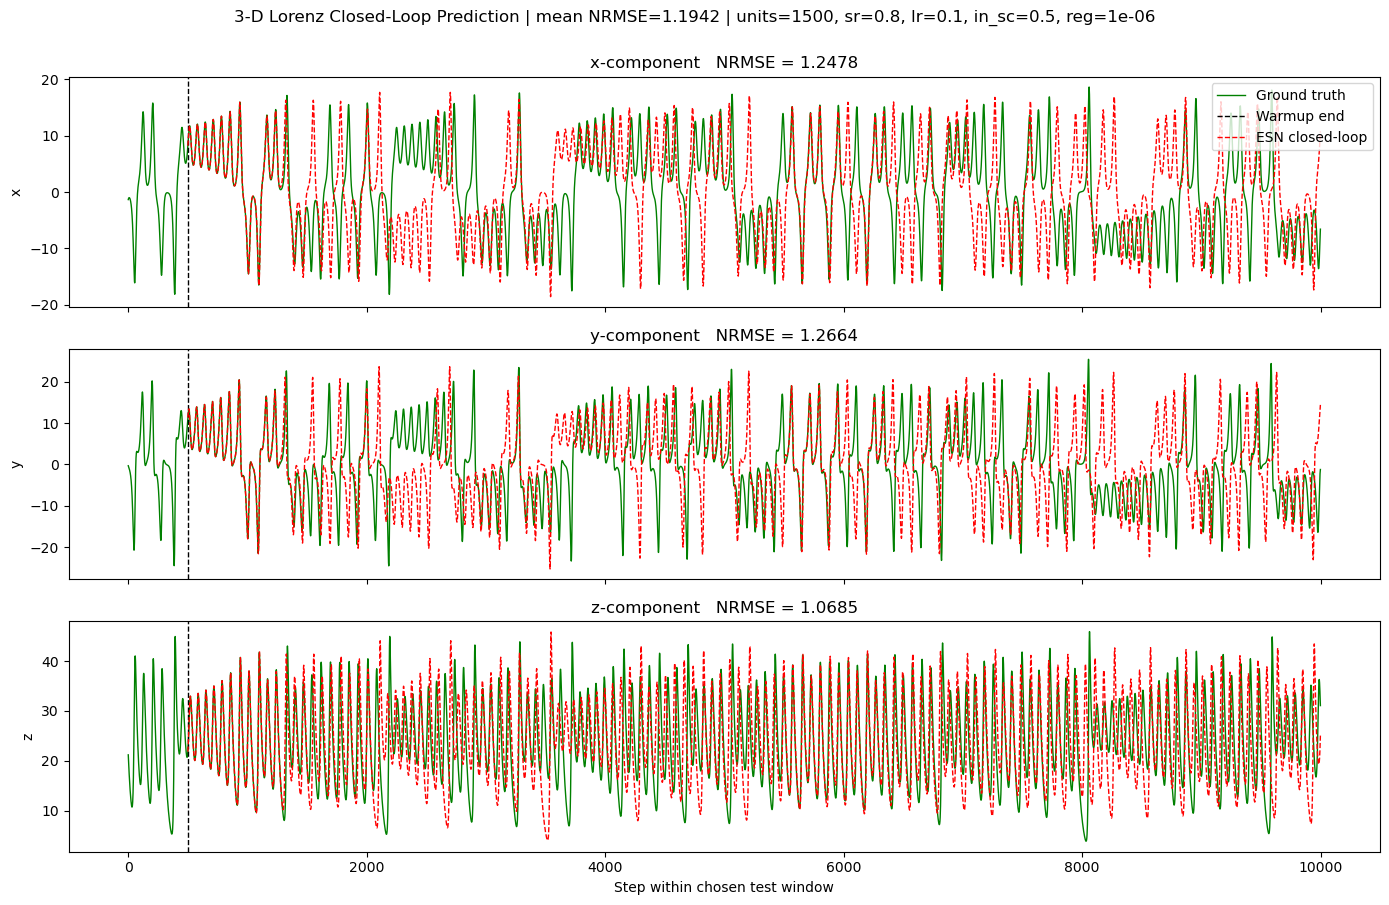

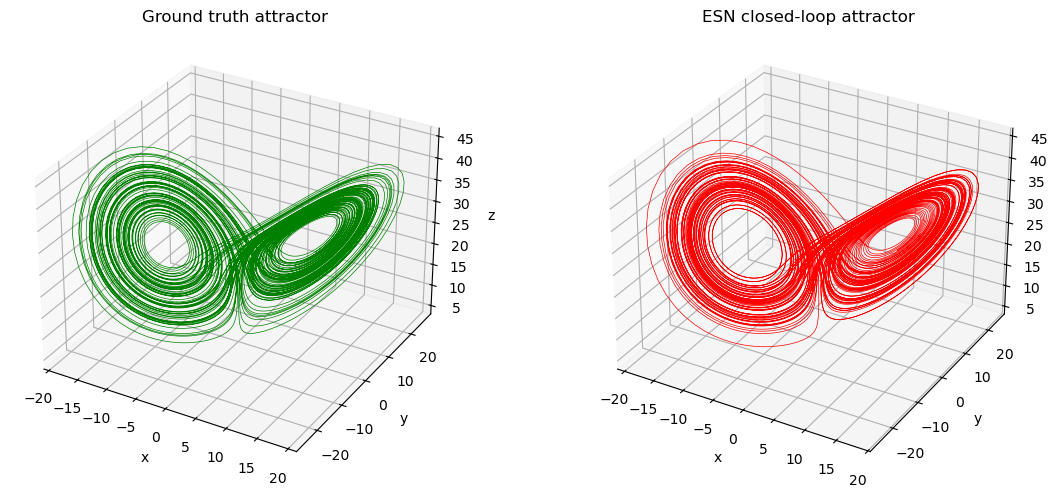

In [10]:
# ==========================================================
# DATA PREPARATION
# ==========================================================
# 3-D Lorenz: data shape is already (T, 3)
data = dataset

# One-step supervised pairs (input -> next-step state)
X_raw = data[:-1]   # shape (T-1, 3)
Y_raw = data[1:]    # shape (T-1, 3)


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len = 10000
test_start = 10000
test_len = 10000

regression_model = "ridge"
seed = 42

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]

X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]

# Output dimensionality (Lorenz = 3)
n_dim = X_train_raw.shape[1]


# ==========================================================
# PARAMETER GRID
# ==========================================================
param_grid = {
    "normalization":          ["zscore"],
    "train_warmup":           [500],
    "test_warmup":            [500],
    "units":                  [500, 1000, 1500],
    "reservoir_connectivity": [0.2, 0.5, 0.8, 1.0],
    "sr":                     [0.8, 0.9, 0.95, 1.0, 1.2, 1.3],
    "lr":                     [0.1, 0.3, 0.5],
    "input_scaling":          [0.5, 0.8, 1.0],
    "regression":             [1e-8, 1e-6, 1e-5],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION (3-D)
# ==========================================================
def evaluate_esn(
    normalization,
    train_warmup,
    test_warmup,
    units,
    reservoir_connectivity,
    sr,
    lr,
    input_scaling,
    regression,
    seed=42
):
    """
    Build, train, synchronize, and run closed-loop prediction on 3-D Lorenz.
    Returns NRMSE in scaled space, averaged over the 3 components.
    """
    try:
        if test_warmup >= test_len:
            return np.inf

        # -------------------------
        # Fit scaler on training inputs only (per-dimension)
        # -------------------------
        scaler = fit_scaler(X_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw,  scaler)
        Y_test  = transform_array(Y_test_raw,  scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, :]   # (pred_len, 3)

        if train_warmup >= len(X_train):
            return np.inf

        # -------------------------
        # Reservoir
        # -------------------------
        reservoir = Reservoir(
            units=int(units),
            lr=lr,
            W=uniform(low=-0.5, high=0.5,
                      connectivity=reservoir_connectivity, sr=sr),
            Win=uniform(low=-0.5 * input_scaling, high=0.5 * input_scaling,
                        connectivity=1.0),
            bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
            activation="tanh",
            seed=seed
        )

        if regression_model == "ridge":
            readout = Ridge(ridge=regression)
        else:
            readout = ScikitLearnNode(model=Lasso, alpha=regression,
                                      max_iter=50000, tol=1e-3)

        esn = reservoir >> readout

        # -------------------------
        # Train: reservoirpy automatically handles 3-D input/output
        # -------------------------
        esn.fit(X_train, Y_train, warmup=train_warmup)

        # -------------------------
        # Test: reset + synchronize + closed loop
        # -------------------------
        esn.reset()

        if test_warmup > 0:
            esn.run(X_test[:test_warmup])

        # Start closed loop from the first test point after warmup
        current_input = X_test[test_warmup:test_warmup + 1]   # shape (1, 3)
        Y_pred_scaled = np.zeros((pred_len, n_dim))

        for t in range(pred_len):
            pred = esn.run(current_input)
            pred = np.asarray(pred).reshape(1, n_dim)
            Y_pred_scaled[t, :] = pred[0, :]
            current_input = pred   # feed prediction back as next input

        # Divergence check
        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf

        # NRMSE per-dimension, then average
        rmse_per_dim = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2, axis=0))
        std_per_dim  = np.std(Y_true_scaled, axis=0)
        if np.any(std_per_dim == 0):
            return np.inf

        nrmse_per_dim = rmse_per_dim / std_per_dim
        return float(np.mean(nrmse_per_dim))

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params, seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
              f"current best NRMSE: {best_nrmse:.6f}")

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE (3-D Lorenz)")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s "
      f"({total_time/len(combos):.2f}s per trial)")
print(f"Regression model    : {regression_model}")
print(f"Best mean NRMSE     : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'norm':>8}  {'tr_wu':>5}  {'te_wu':>5}  "
      f"{'units':>5}  {'conn':>5}  {'sr':>4}  {'lr':>4}  "
      f"{'in_sc':>6}  {'reg':>8}  {'NRMSE':>10}")
print("-" * 100)
for rank, r in enumerate(results_sorted[:10], 1):
    print(f"{rank:4d}  {r['normalization']:>8s}  "
          f"{r['train_warmup']:5d}  {r['test_warmup']:5d}  "
          f"{int(r['units']):5d}  {r['reservoir_connectivity']:5.2f}  "
          f"{r['sr']:4.2f}  {r['lr']:4.1f}  {r['input_scaling']:6.2f}  "
          f"{r['regression']:8.1e}  {r['nrmse']:10.6f}")


# ==========================================================
# REBUILD BEST MODEL
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])

X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best  = transform_array(X_test_raw,  best_scaler)
Y_test_best  = transform_array(Y_test_raw,  best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_reservoir = Reservoir(
    units=int(best_params["units"]),
    lr=best_params["lr"],
    W=uniform(low=-0.5, high=0.5,
              connectivity=best_params["reservoir_connectivity"],
              sr=best_params["sr"]),
    Win=uniform(low=-0.5 * best_params["input_scaling"],
                high=0.5 * best_params["input_scaling"],
                connectivity=1.0),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=seed
)

if regression_model == "ridge":
    best_readout = Ridge(ridge=best_params["regression"])
else:
    best_readout = ScikitLearnNode(model=Lasso,
                                   alpha=best_params["regression"],
                                   max_iter=10000)

best_esn = best_reservoir >> best_readout

best_esn.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])

best_esn.reset()
if best_params["test_warmup"] > 0:
    best_esn.run(X_test_best[:best_params["test_warmup"]])

Y_pred_best_scaled = np.zeros((best_pred_len, n_dim))
current_input = X_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + 1
]

for t in range(best_pred_len):
    pred = best_esn.run(current_input)
    pred = np.asarray(pred).reshape(1, n_dim)
    Y_pred_best_scaled[t, :] = pred[0, :]
    current_input = pred

Y_true_best_scaled = Y_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len, :
]

# Inverse transform back to original scale (per dimension)
Y_pred_best = inverse_transform_array(Y_pred_best_scaled, best_scaler)
Y_true_best = inverse_transform_array(Y_true_best_scaled, best_scaler)

# Per-dimension and aggregate metrics in original scale
rmse_per_dim = np.sqrt(np.mean((Y_true_best - Y_pred_best) ** 2, axis=0))
std_per_dim  = np.std(Y_true_best, axis=0)
nrmse_per_dim = rmse_per_dim / std_per_dim

print("\nFinal best-model metrics in original scale:")
for d in range(n_dim):
    print(f"  {dim_names[d]}: RMSE={rmse_per_dim[d]:.6f}   "
          f"NRMSE={nrmse_per_dim[d]:.6f}")
print(f"  mean NRMSE = {np.mean(nrmse_per_dim):.6f}")


# ==========================================================
# VISUALIZATION: 3 PANELS, ONE PER COMPONENT
# ==========================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

t_full = np.arange(test_len)
t_pred = np.arange(best_params["test_warmup"],
                   best_params["test_warmup"] + best_pred_len)

for d in range(n_dim):
    ax = axes[d]
    ax.plot(t_full, Y_test_raw[:, d],
            c="green", linewidth=1.0, label="Ground truth")
    ax.axvline(best_params["test_warmup"], linestyle="--",
               c="k", linewidth=1.0, label="Warmup end")
    ax.plot(t_pred, Y_pred_best[:, d], linestyle="--",
            c="red", linewidth=1.0, label="ESN closed-loop")
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}-component   "
                 f"NRMSE = {nrmse_per_dim[d]:.4f}")
    if d == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Step within chosen test window")

fig.suptitle(
    f"3-D Lorenz Closed-Loop Prediction | mean NRMSE={np.mean(nrmse_per_dim):.4f} | "
    f"units={int(best_params['units'])}, "
    f"sr={best_params['sr']}, lr={best_params['lr']}, "
    f"in_sc={best_params['input_scaling']}, "
    f"reg={best_params['regression']:.0e}",
    y=1.00
)

plt.tight_layout()
plt.show()


# ==========================================================
# OPTIONAL: 3-D ATTRACTOR COMPARISON
# ==========================================================
# Useful sanity check: do the reconstructed dynamics live on the
# Lorenz butterfly, or has the RC drifted to a different attractor?
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(Y_true_best[:, 0], Y_true_best[:, 1], Y_true_best[:, 2],
         color='green', linewidth=0.5)
ax1.set_title('Ground truth attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(Y_pred_best[:, 0], Y_pred_best[:, 1], Y_pred_best[:, 2],
         color='red', linewidth=0.5)
ax2.set_title('ESN closed-loop attractor')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

## Synchronization

Warm-up + uncoupled transient complete:
  RC 1 from offset 10: y_init = [-0.028 -0.097 -0.987]
  RC 2 from offset 1000: y_init = [-0.778 -0.973 -0.394]
  ||r1_on - r2_on|| = 8.789

Simulation complete: 4000 steps, alpha = 0.02
  E (full window)        = 2.42787
  E (second half only)   = 2.40302
  ||y1 - y2|| at start   = 1.29638
  ||y1 - y2|| at end     = 2.79727
  Std of y1[:,0] late    = 0.8386
  Std of y2[:,0] late    = 0.1233


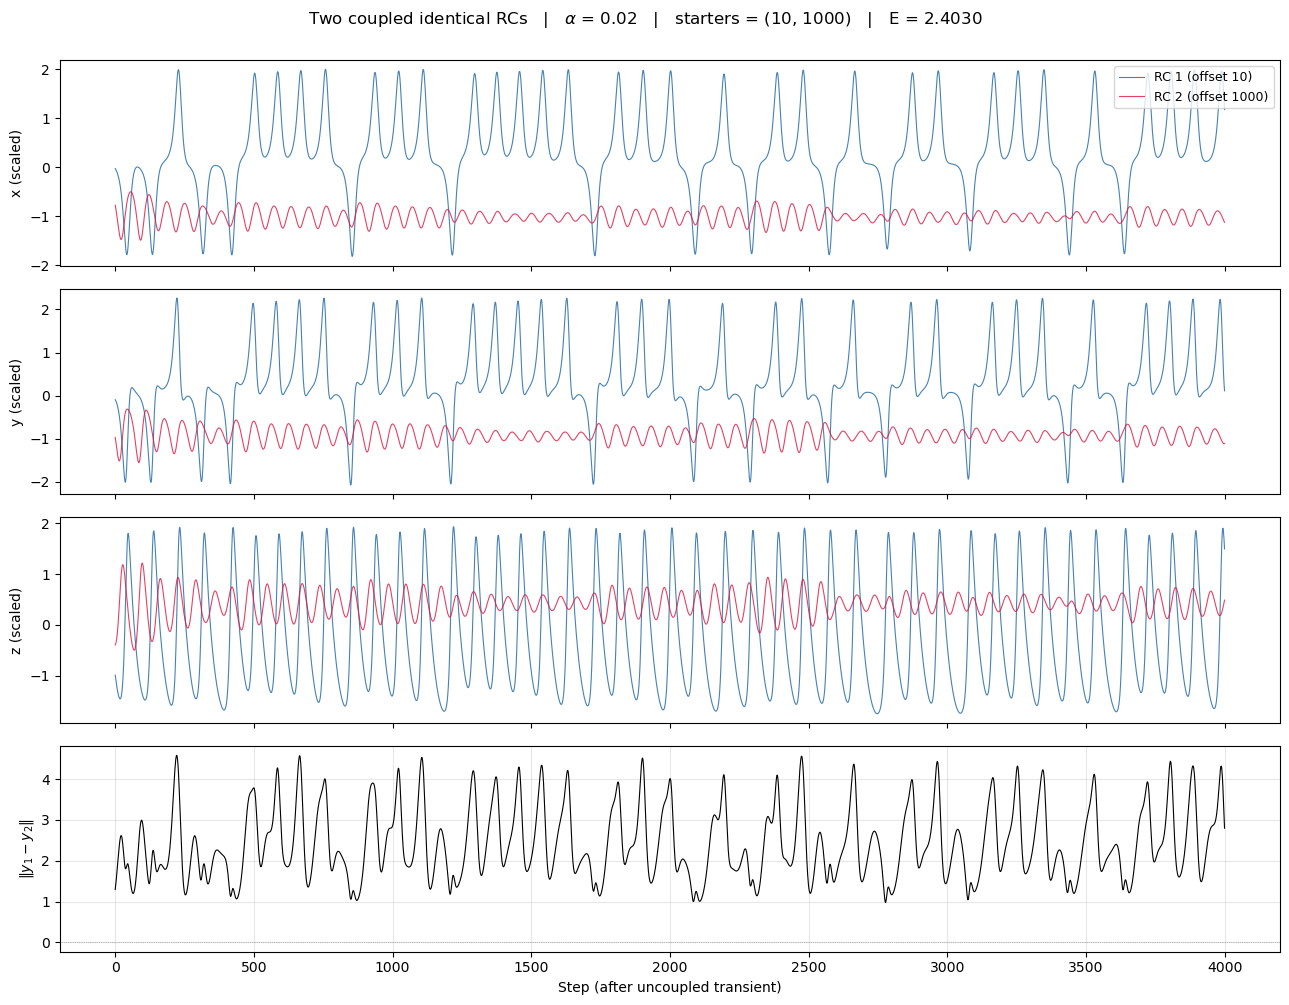

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PREREQUISITES (from earlier cells)
# ==========================================================
# Assumes these are already in memory:
#   W_res, W_in, b_res, W_out, b_out  - extracted reservoir weights
#   leak                              - leak rate
#   N                                 - reservoir size
#   X_train_best                      - scaled training data (T, 3)
#   reservoir_step, readout           - helper functions

# ==========================================================
# ADJUSTABLE PARAMETERS — change these and re-run the cell
# ==========================================================
alpha           = 0.02      # coupling strength (0 = uncoupled)

starter_offset_1 = 10       # warm-up window start for RC 1
starter_offset_2 = 1000      # warm-up window start for RC 2

warmup_len      = 500       # warm-up duration (steps)
n_transient     = 4000      # uncoupled closed-loop steps to land on the RC's attractor
n_steps         = 4000      # length of coupled simulation to plot
plot_steps      = 4000      # how many steps of the coupled result to display

# ==========================================================
# WARM UP TWO RESERVOIRS WITH DIFFERENT SEGMENTS
# ==========================================================
def warmup_reservoir(driving_signal, W_res, W_in, b_res, leak, N):
    r = np.zeros(N)
    for u in driving_signal:
        r = reservoir_step(r, u, W_res, W_in, b_res, leak)
    return r

# Validate offsets fit in the warm-up source
assert starter_offset_1 + warmup_len <= len(X_train_best), \
    f"starter_offset_1 + warmup_len exceeds data length {len(X_train_best)}"
assert starter_offset_2 + warmup_len <= len(X_train_best), \
    f"starter_offset_2 + warmup_len exceeds data length {len(X_train_best)}"

seg1 = X_train_best[starter_offset_1:starter_offset_1 + warmup_len]
seg2 = X_train_best[starter_offset_2:starter_offset_2 + warmup_len]

r1_0 = warmup_reservoir(seg1, W_res, W_in, b_res, leak, N)
r2_0 = warmup_reservoir(seg2, W_res, W_in, b_res, leak, N)

# ==========================================================
# UNCOUPLED CLOSED-LOOP TRANSIENT
# ==========================================================
# Each RC runs autonomously (alpha = 0) for n_transient steps to settle
# onto its own chaotic attractor. This is the analogue of the uncoupled
# pre-integration we did for the true Lorenz system: it ensures that
# both reservoirs start the coupled simulation from genuinely on-attractor
# states, avoiding any degenerate basin in the coupled dynamics.
def closed_loop_uncoupled(r0, n_steps, W_res, W_in, b_res, W_out, b_out, leak):
    r = r0.copy()
    for _ in range(n_steps):
        y = readout(r, W_out, b_out)
        r = reservoir_step(r, y, W_res, W_in, b_res, leak)
        if not np.all(np.isfinite(y)):
            return None
    return r

r1_on = closed_loop_uncoupled(r1_0, n_transient,
                              W_res, W_in, b_res, W_out, b_out, leak)
r2_on = closed_loop_uncoupled(r2_0, n_transient + 200,    # +200 offset for variety
                              W_res, W_in, b_res, W_out, b_out, leak)

assert r1_on is not None and r2_on is not None, \
    "RC diverged during uncoupled transient — check training quality."

y1_init = readout(r1_on, W_out, b_out)
y2_init = readout(r2_on, W_out, b_out)

print(f"Warm-up + uncoupled transient complete:")
print(f"  RC 1 from offset {starter_offset_1}: "
      f"y_init = [{y1_init[0]:+.3f} {y1_init[1]:+.3f} {y1_init[2]:+.3f}]")
print(f"  RC 2 from offset {starter_offset_2}: "
      f"y_init = [{y2_init[0]:+.3f} {y2_init[1]:+.3f} {y2_init[2]:+.3f}]")
print(f"  ||r1_on - r2_on|| = {np.linalg.norm(r1_on - r2_on):.3f}")

# ==========================================================
# COUPLED CLOSED-LOOP SIMULATION
# ==========================================================
r1 = r1_on.copy()
r2 = r2_on.copy()

y1_traj = np.zeros((n_steps, 3))
y2_traj = np.zeros((n_steps, 3))

diverged = False
for t in range(n_steps):
    y1 = readout(r1, W_out, b_out)
    y2 = readout(r2, W_out, b_out)

    # Eq. 6 of the paper, H = I, output coupling
    u1 = y1 + alpha * (y2 - y1)
    u2 = y2 + alpha * (y1 - y2)

    r1 = reservoir_step(r1, u1, W_res, W_in, b_res, leak)
    r2 = reservoir_step(r2, u2, W_res, W_in, b_res, leak)

    y1_traj[t] = y1
    y2_traj[t] = y2

    if not (np.all(np.isfinite(y1)) and np.all(np.isfinite(y2))):
        print(f"  ✗ diverged at step {t}")
        y1_traj = y1_traj[:t]
        y2_traj = y2_traj[:t]
        diverged = True
        break

# ==========================================================
# DIAGNOSTICS
# ==========================================================
if not diverged:
    diff = np.linalg.norm(y1_traj - y2_traj, axis=1)
    E_full   = float(np.mean(diff))
    E_late   = float(np.mean(diff[len(diff) // 2:]))
    print(f"\nSimulation complete: {n_steps} steps, alpha = {alpha}")
    print(f"  E (full window)        = {E_full:.5f}")
    print(f"  E (second half only)   = {E_late:.5f}")
    print(f"  ||y1 - y2|| at start   = {diff[0]:.5f}")
    print(f"  ||y1 - y2|| at end     = {diff[-1]:.5f}")
    print(f"  Std of y1[:,0] late    = {y1_traj[len(y1_traj)//2:, 0].std():.4f}")
    print(f"  Std of y2[:,0] late    = {y2_traj[len(y2_traj)//2:, 0].std():.4f}")

# ==========================================================
# PLOT: 3 COMPONENTS OVERLAID + DISTANCE OVER TIME
# ==========================================================
n_plot = min(plot_steps, len(y1_traj))
t_axis = np.arange(n_plot)
dim_names = ['x', 'y', 'z']

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for d in range(3):
    ax = axes[d]
    ax.plot(t_axis, y1_traj[:n_plot, d], color='steelblue',
            linewidth=0.8, label=f'RC 1 (offset {starter_offset_1})')
    ax.plot(t_axis, y2_traj[:n_plot, d], color='crimson',
            linewidth=0.8, alpha=0.8,
            label=f'RC 2 (offset {starter_offset_2})')
    ax.set_ylabel(f'{dim_names[d]} (scaled)')
    if d == 0:
        ax.legend(loc='upper right', fontsize=9)

if not diverged:
    diff = np.linalg.norm(y1_traj - y2_traj, axis=1)
    axes[3].plot(np.arange(len(diff))[:n_plot], diff[:n_plot],
                 color='black', linewidth=0.8)
    axes[3].set_ylabel(r'$\|y_1 - y_2\|$')
    axes[3].axhline(0, color='gray', linestyle=':', linewidth=0.5)
    axes[3].grid(alpha=0.3)
else:
    axes[3].text(0.5, 0.5, 'diverged', ha='center', va='center',
                 transform=axes[3].transAxes)

axes[-1].set_xlabel('Step (after uncoupled transient)')

fig.suptitle(
    f'Two coupled identical RCs   |   '
    fr'$\alpha$ = {alpha}   |   '
    f'starters = ({starter_offset_1}, {starter_offset_2})   |   '
    + (f'E = {E_late:.4f}' if not diverged else 'DIVERGED'),
    y=1.00
)
plt.tight_layout()
plt.savefig("lorenz_ESN_async.png")
plt.show()

Preparing initial-state pairs (same warm-up, varying transient lengths)
  pair 0: extras=(0,200)   ||r1-r2||=  3.813   y1=[-0.03 -0.10 -0.99]   y2=[+0.47 +0.67 -1.26]
  pair 1: extras=(300,500)   ||r1-r2||=  4.698   y1=[+0.18 +0.40 -0.12]   y2=[+0.31 +0.42 -0.72]
  pair 2: extras=(600,900)   ||r1-r2||= 15.757   y1=[+0.23 -0.15 +0.19]   y2=[-1.64 -1.68 +0.89]
  pair 3: extras=(1000,1300)   ||r1-r2||=  4.295   y1=[+0.21 +0.42 -0.14]   y2=[-0.46 -0.22 +0.14]
  pair 4: extras=(1500,1800)   ||r1-r2||= 20.052   y1=[+1.57 +2.19 -0.30]   y2=[-0.88 -0.02 +1.11]

Prepared 5 initial-state pairs

Sanity check: per-pair uncoupled std (should be similar for all pairs)
  pair 0: std1=0.9904  std2=1.0042  E0=2.3026  ✓ chaotic
  pair 1: std1=0.9547  std2=0.9689  E0=2.2813  ✓ chaotic
  pair 2: std1=0.9543  std2=0.9096  E0=2.0954  ✓ chaotic
  pair 3: std1=0.9634  std2=0.9167  E0=1.9843  ✓ chaotic
  pair 4: std1=0.9847  std2=0.9936  E0=2.0558  ✓ chaotic

Alpha sweep over 22 values: 0.000 ... 0.105, step 0

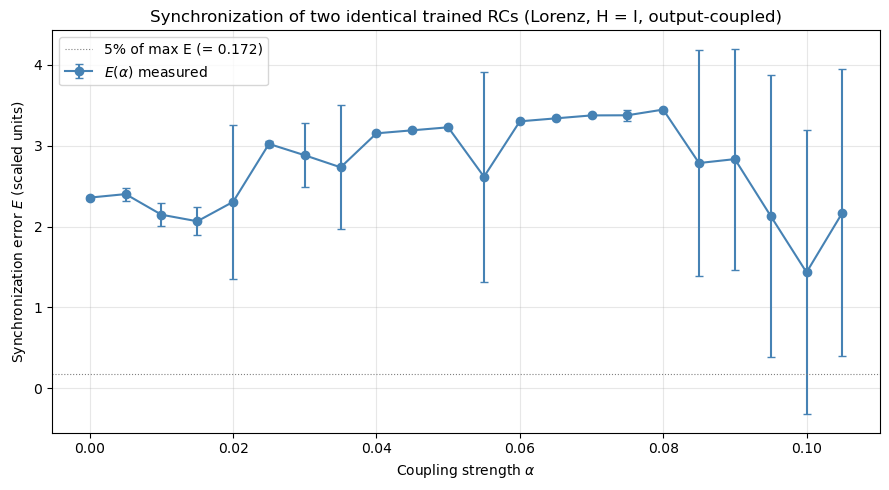

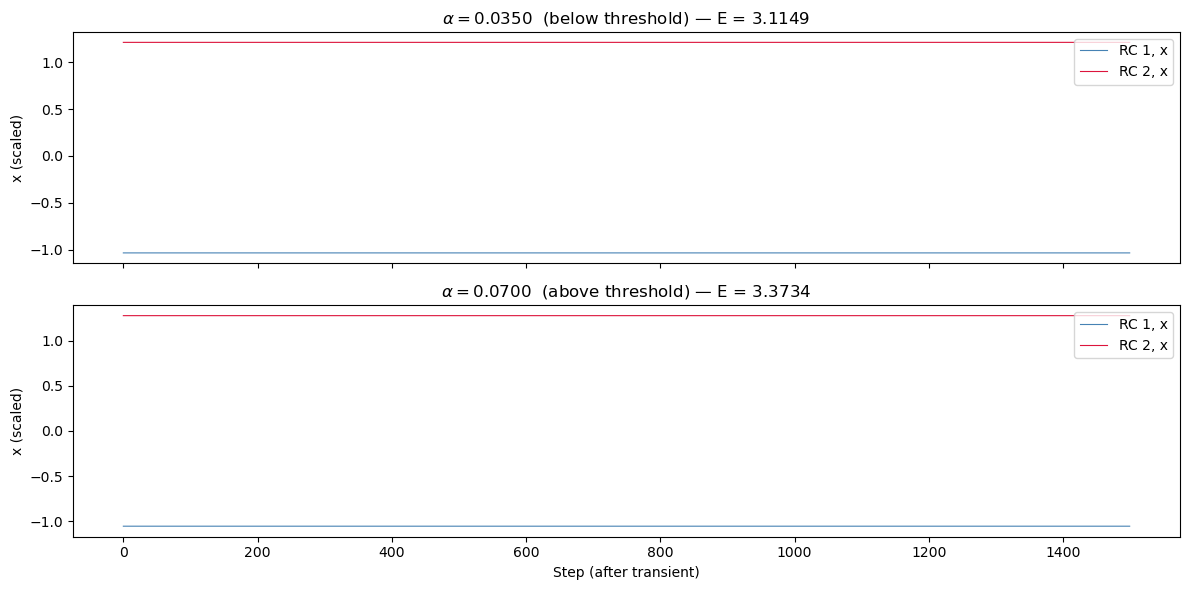

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================================
# PREREQUISITES (from earlier cells)
# ==========================================================
# Assumes these are already in memory:
#   W_res, W_in, b_res, W_out, b_out, leak, N
#   reservoir_step, readout
#   X_train_best  - scaled training data (T, 3)

# ==========================================================
# HELPERS
# ==========================================================
def warmup_reservoir(driving_signal, W_res, W_in, b_res, leak, N):
    """Drive a fresh reservoir with `driving_signal` and return final state."""
    r = np.zeros(N)
    for u in driving_signal:
        r = reservoir_step(r, u, W_res, W_in, b_res, leak)
    return r

def closed_loop_uncoupled(r0, n_steps, W_res, W_in, b_res,
                          W_out, b_out, leak):
    """Run a single RC autonomously (no coupling) for n_steps."""
    r = r0.copy()
    for _ in range(n_steps):
        y = readout(r, W_out, b_out)
        r = reservoir_step(r, y, W_res, W_in, b_res, leak)
        if not np.all(np.isfinite(y)):
            return None
    return r

def simulate_coupled_pair(r1_0, r2_0, alpha, n_steps,
                          W_res, W_in, b_res, W_out, b_out, leak,
                          divergence_bound=1e4):
    """Two identical ESNs in closed loop, output-coupled with H = I."""
    r1 = r1_0.copy()
    r2 = r2_0.copy()
    y1_traj = np.zeros((n_steps, 3))
    y2_traj = np.zeros((n_steps, 3))

    for t in range(n_steps):
        y1 = readout(r1, W_out, b_out)
        y2 = readout(r2, W_out, b_out)
        u1 = y1 + alpha * (y2 - y1)
        u2 = y2 + alpha * (y1 - y2)
        r1 = reservoir_step(r1, u1, W_res, W_in, b_res, leak)
        r2 = reservoir_step(r2, u2, W_res, W_in, b_res, leak)
        y1_traj[t] = y1
        y2_traj[t] = y2
        if (not np.all(np.isfinite(y1))) or (not np.all(np.isfinite(y2))):
            return None, None
        if max(np.max(np.abs(y1)), np.max(np.abs(y2))) > divergence_bound:
            return None, None
    return y1_traj, y2_traj

def sync_error(y1_traj, y2_traj, transient):
    """E = mean ||y1(t) - y2(t)|| over t > transient."""
    if y1_traj is None or y2_traj is None:
        return np.nan
    diff = y1_traj[transient:] - y2_traj[transient:]
    return float(np.mean(np.linalg.norm(diff, axis=1)))


# ==========================================================
# PARAMETERS — match the single-alpha cell that works
# ==========================================================
warmup_len            = 500
n_uncoupled_transient = 4000   # same as single-alpha cell
warmup_offset_1       = 10
warmup_offset_2       = 100

# Coupled-simulation budget
coupled_transient = 4000   # same as single-alpha cell's "second half" choice
average_steps     = 4000
n_steps           = coupled_transient + average_steps

# Sweep range
alpha_values = np.arange(0.0, 0.11, 0.005)

# ==========================================================
# PREPARE INITIAL-STATE PAIRS
# ==========================================================
# Use ONE warm-up endpoint per reservoir (matching the working cell),
# and generate variety across realizations by varying the uncoupled
# transient length. This keeps both reservoirs in the SAME basin
# (the chaotic one) across all realizations — what the single-alpha
# cell does implicitly.
print("Preparing initial-state pairs (same warm-up, varying transient lengths)")

assert warmup_offset_1 + warmup_len <= len(X_train_best)
assert warmup_offset_2 + warmup_len <= len(X_train_best)

seg1 = X_train_best[warmup_offset_1:warmup_offset_1 + warmup_len]
seg2 = X_train_best[warmup_offset_2:warmup_offset_2 + warmup_len]

# Compute the two warm-up endpoints once
r1_warm = warmup_reservoir(seg1, W_res, W_in, b_res, leak, N)
r2_warm = warmup_reservoir(seg2, W_res, W_in, b_res, leak, N)

# Generate realizations by extending the uncoupled transient by
# different amounts. Each pair (a, b) gives r1 transient = base + a,
# r2 transient = base + b. Different transient lengths → different
# on-attractor points, but always in the chaotic basin.
transient_offsets_per_pair = [
    (0,    200),
    (300,  500),
    (600,  900),
    (1000, 1300),
    (1500, 1800),
]

initial_state_pairs = []
for k, (extra1, extra2) in enumerate(transient_offsets_per_pair):
    r1_on = closed_loop_uncoupled(r1_warm,
                                  n_uncoupled_transient + extra1,
                                  W_res, W_in, b_res, W_out, b_out, leak)
    r2_on = closed_loop_uncoupled(r2_warm,
                                  n_uncoupled_transient + extra2,
                                  W_res, W_in, b_res, W_out, b_out, leak)
    if r1_on is None or r2_on is None:
        print(f"  pair {k}: uncoupled transient diverged — skipping")
        continue

    initial_state_pairs.append((r1_on, r2_on))

    y1 = readout(r1_on, W_out, b_out)
    y2 = readout(r2_on, W_out, b_out)
    print(f"  pair {k}: extras=({extra1},{extra2})   "
          f"||r1-r2||={np.linalg.norm(r1_on - r2_on):7.3f}   "
          f"y1=[{y1[0]:+.2f} {y1[1]:+.2f} {y1[2]:+.2f}]   "
          f"y2=[{y2[0]:+.2f} {y2[1]:+.2f} {y2[2]:+.2f}]")

assert len(initial_state_pairs) > 0, "No usable initial-state pairs!"
print(f"\nPrepared {len(initial_state_pairs)} initial-state pairs")


# ==========================================================
# SANITY CHECK: are all pairs really in the chaotic basin?
# ==========================================================
print("\nSanity check: per-pair uncoupled std (should be similar for all pairs)")
for k, (r1_0, r2_0) in enumerate(initial_state_pairs):
    y1, y2 = simulate_coupled_pair(r1_0, r2_0, 0.0, 3000,
                                   W_res, W_in, b_res,
                                   W_out, b_out, leak)
    if y1 is None:
        print(f"  pair {k}: DIVERGED")
        continue
    std1 = y1[1000:, 0].std()
    std2 = y2[1000:, 0].std()
    e0   = sync_error(y1, y2, 1000)
    flag = "✓ chaotic" if (std1 > 0.4 and std2 > 0.4) else "✗ COLLAPSED"
    print(f"  pair {k}: std1={std1:.4f}  std2={std2:.4f}  "
          f"E0={e0:.4f}  {flag}")


# ==========================================================
# ALPHA SWEEP
# ==========================================================
print(f"\nAlpha sweep over {len(alpha_values)} values: "
      f"{alpha_values[0]:.3f} ... {alpha_values[-1]:.3f}, "
      f"step {alpha_values[1] - alpha_values[0]:.3f}")
print(f"Per simulation: {n_steps} steps "
      f"({coupled_transient} transient + {average_steps} averaging)")

t_start = time.time()
E_mean         = np.full(len(alpha_values), np.nan)
E_std          = np.full(len(alpha_values), np.nan)
diverged_count = np.zeros(len(alpha_values), dtype=int)

for i, alpha in enumerate(alpha_values):
    E_realizations = []
    for (r1_0, r2_0) in initial_state_pairs:
        y1, y2 = simulate_coupled_pair(
            r1_0, r2_0, alpha, n_steps,
            W_res, W_in, b_res, W_out, b_out, leak
        )
        if y1 is None:
            diverged_count[i] += 1
            E_realizations.append(np.nan)
        else:
            E_realizations.append(sync_error(y1, y2, coupled_transient))

    E_realizations = np.array(E_realizations)
    valid = E_realizations[np.isfinite(E_realizations)]
    if len(valid) > 0:
        E_mean[i] = np.mean(valid)
        E_std[i]  = np.std(valid)

    elapsed = time.time() - t_start
    div_str = (f" [{diverged_count[i]}/{len(initial_state_pairs)} diverged]"
               if diverged_count[i] > 0 else "")
    print(f"  [{i+1:2d}/{len(alpha_values)}] alpha = {alpha:.4f}  "
          f"E = {E_mean[i]:.5f} ± {E_std[i]:.5f}{div_str}  "
          f"(elapsed {elapsed:.0f}s)")


# ==========================================================
# CRITICAL ALPHA + PLOT
# ==========================================================
E_max     = np.nanmax(E_mean)
threshold = 0.05 * E_max
below = np.where(E_mean < threshold)[0]
alpha_c_emp = alpha_values[below[0]] if len(below) > 0 else None

if alpha_c_emp is not None:
    print(f"\nEmpirical critical alpha (E < 5% of max E):  "
          f"alpha_c ≈ {alpha_c_emp:.4f}")
else:
    print(f"\nNo alpha in the swept range produced E < {threshold:.4f}.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(alpha_values, E_mean, yerr=E_std,
            marker='o', linewidth=1.5, capsize=3,
            color='steelblue', label=r'$E(\alpha)$ measured')
if alpha_c_emp is not None:
    ax.axvline(alpha_c_emp, color='green', linestyle=':', linewidth=1.5,
               label=fr'Empirical $\alpha_c \approx {alpha_c_emp:.4f}$')
ax.axhline(threshold, color='gray', linestyle=':', linewidth=0.8,
           label=f'5% of max E (= {threshold:.3f})')
ax.set_xlabel(r'Coupling strength $\alpha$')
ax.set_ylabel(r'Synchronization error $E$ (scaled units)')
ax.set_title('Synchronization of two identical trained RCs '
             '(Lorenz, H = I, output-coupled)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================================
# DIAGNOSTIC: TRAJECTORIES BELOW AND ABOVE THRESHOLD
# ==========================================================
alpha_below = alpha_values[max(0, len(alpha_values) // 3)]
alpha_above = alpha_values[min(len(alpha_values) - 1,
                               2 * len(alpha_values) // 3)]
if alpha_c_emp is not None:
    idx_c = int(np.argmin(np.abs(alpha_values - alpha_c_emp)))
    if idx_c >= 2:
        alpha_below = alpha_values[idx_c - 2]
    if idx_c <= len(alpha_values) - 3:
        alpha_above = alpha_values[idx_c + 2]

r1_0, r2_0 = initial_state_pairs[0]
y1_lo, y2_lo = simulate_coupled_pair(r1_0, r2_0, alpha_below, n_steps,
                                     W_res, W_in, b_res,
                                     W_out, b_out, leak)
y1_hi, y2_hi = simulate_coupled_pair(r1_0, r2_0, alpha_above, n_steps,
                                     W_res, W_in, b_res,
                                     W_out, b_out, leak)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
window = slice(coupled_transient, coupled_transient + 1500)
t_axis = np.arange(window.stop - window.start)

if y1_lo is not None:
    axes[0].plot(t_axis, y1_lo[window, 0], color='steelblue',
                 linewidth=0.8, label='RC 1, x')
    axes[0].plot(t_axis, y2_lo[window, 0], color='crimson',
                 linewidth=0.8, label='RC 2, x')
    e_lo = sync_error(y1_lo, y2_lo, coupled_transient)
    axes[0].set_title(fr'$\alpha = {alpha_below:.4f}$  '
                      fr'(below threshold) — E = {e_lo:.4f}')
axes[0].legend(loc='upper right')
axes[0].set_ylabel('x (scaled)')

if y1_hi is not None:
    axes[1].plot(t_axis, y1_hi[window, 0], color='steelblue',
                 linewidth=0.8, label='RC 1, x')
    axes[1].plot(t_axis, y2_hi[window, 0], color='crimson',
                 linewidth=0.8, label='RC 2, x')
    e_hi = sync_error(y1_hi, y2_hi, coupled_transient)
    axes[1].set_title(fr'$\alpha = {alpha_above:.4f}$  '
                      fr'(above threshold) — E = {e_hi:.4f}')
axes[1].legend(loc='upper right')
axes[1].set_ylabel('x (scaled)')
axes[1].set_xlabel('Step (after transient)')

plt.tight_layout()
plt.show()